<a href="https://colab.research.google.com/github/tatyanakrivonogova/machine-learning-methods/blob/master/%D0%91%D0%BB%D0%BE%D0%BA_4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Нейронная сеть прямого распространения (классификация)
Многослойный перцептрон представляет собой нейронную сеть прямого распространения, состоящую из входного слоя, одного или нескольких скрытых слоёв и выходного слоя. Обучение выполняется методом обратного распространения ошибки с использованием оптимизатора на основе градиентного спуска.

### Используемые библиотеки

In [176]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, recall_score, classification_report, confusion_matrix, roc_curve, auc
from sklearn.model_selection import GridSearchCV

### Датасет

In [177]:
data = load_breast_cancer()
X = data.data
y = data.target
feature_names = data.feature_names
target_names = data.target_names

print("Название датасета: Breast Cancer Wisconsin (Diagnostic)")
print("Количество образцов:", X.shape)
print("Классы:", target_names)
print("Распределение классов:\n", pd.Series(y).value_counts())
print("\nПервые 5 строк:")
print(pd.DataFrame(X, columns=feature_names).head())

Название датасета: Breast Cancer Wisconsin (Diagnostic)
Количество образцов: (569, 30)
Классы: ['malignant' 'benign']
Распределение классов:
 1    357
0    212
Name: count, dtype: int64

Первые 5 строк:
   mean radius  mean texture  mean perimeter  mean area  mean smoothness  \
0        17.99         10.38          122.80     1001.0          0.11840   
1        20.57         17.77          132.90     1326.0          0.08474   
2        19.69         21.25          130.00     1203.0          0.10960   
3        11.42         20.38           77.58      386.1          0.14250   
4        20.29         14.34          135.10     1297.0          0.10030   

   mean compactness  mean concavity  mean concave points  mean symmetry  \
0           0.27760          0.3001              0.14710         0.2419   
1           0.07864          0.0869              0.07017         0.1812   
2           0.15990          0.1974              0.12790         0.2069   
3           0.28390          0.2414     

### Предварительная обработка датасета

In [178]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Размер обучающей выборки:", X_train_scaled.shape)
print("Размер тестовой выборки:", X_test_scaled.shape)

Размер обучающей выборки: (455, 30)
Размер тестовой выборки: (114, 30)


### Тепловая карта

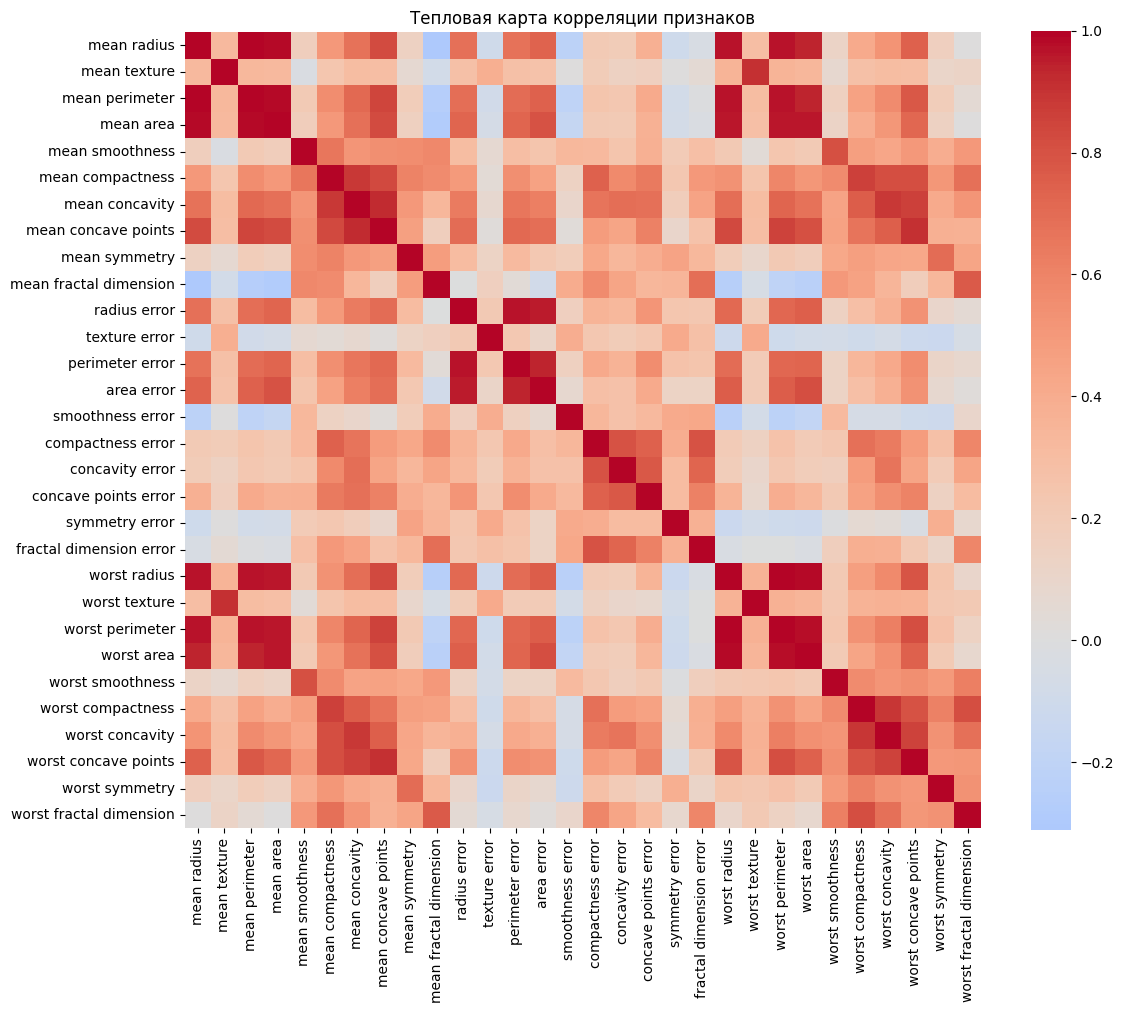

In [179]:
df_features = pd.DataFrame(X, columns=feature_names)
plt.figure(figsize=(12, 10))
sns.heatmap(df_features.corr(), cmap='coolwarm', center=0, annot=False, square=True)
plt.title('Тепловая карта корреляции признаков')
plt.tight_layout()
plt.show()

### Обучение модели

In [180]:
# mlp = MLPClassifier(random_state=42, max_iter=200, verbose=False)

# # Сетка гиперпараметров для перебора
# param_grid = {
#     'hidden_layer_sizes': [(50,), (100,), (50, 50), (100, 50)],   # размеры слоёв
#     'activation': ['relu', 'tanh', 'logistic'],                   # функции активации
#     'solver': ['adam', 'sgd'],                                    # оптимизаторы
#     'alpha': [0.0001, 0.001, 0.01],                               # коэффициент регуляризации
#     'learning_rate_init': [0.001, 0.01],                          # начальная скорость обучения (для sgd)
#     'max_iter': [200, 300]                                        # максимальное число итераций
# }

# # Создание объекта GridSearchCV
# grid_search = GridSearchCV(
#     estimator=mlp,
#     param_grid=param_grid,
#     cv=5,                # 5-кратная кросс-валидация
#     scoring='accuracy',  # метрика качества (можно изменить)
#     n_jobs=-1,           # использовать все доступные ядра
#     verbose=1
# )

# # Запуск подбора
# grid_search.fit(X_train_scaled, y_train)

# # Вывод лучших параметров и лучшей оценки
# print("Лучшие параметры:", grid_search.best_params_)
# print("Лучшая точность на кросс-валидации: {:.3f}".format(grid_search.best_score_))

In [181]:
mlp = MLPClassifier(
    hidden_layer_sizes=(50,),
    activation='logistic',
    alpha=0.0001,
    solver='sgd',
    learning_rate_init=0.01,
    max_iter=200,
    random_state=42,
    verbose=False
)
mlp.fit(X_train_scaled, y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(


MLPClassifier(activation='logistic', hidden_layer_sizes=(50,),
              learning_rate_init=0.01, random_state=42, solver='sgd')

### Прогнозы модели

In [182]:
y_pred = mlp.predict(X_test_scaled)
accuracy = accuracy_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)  # вычисляем полноту

print("Точность на тестовой выборке: {:.2f}%".format(accuracy * 100))
print("Полнота на тестовой выборке: {:.2f}%".format(recall * 100))

Точность на тестовой выборке: 97.37%
Полнота на тестовой выборке: 97.22%


### Графики выходных результатов

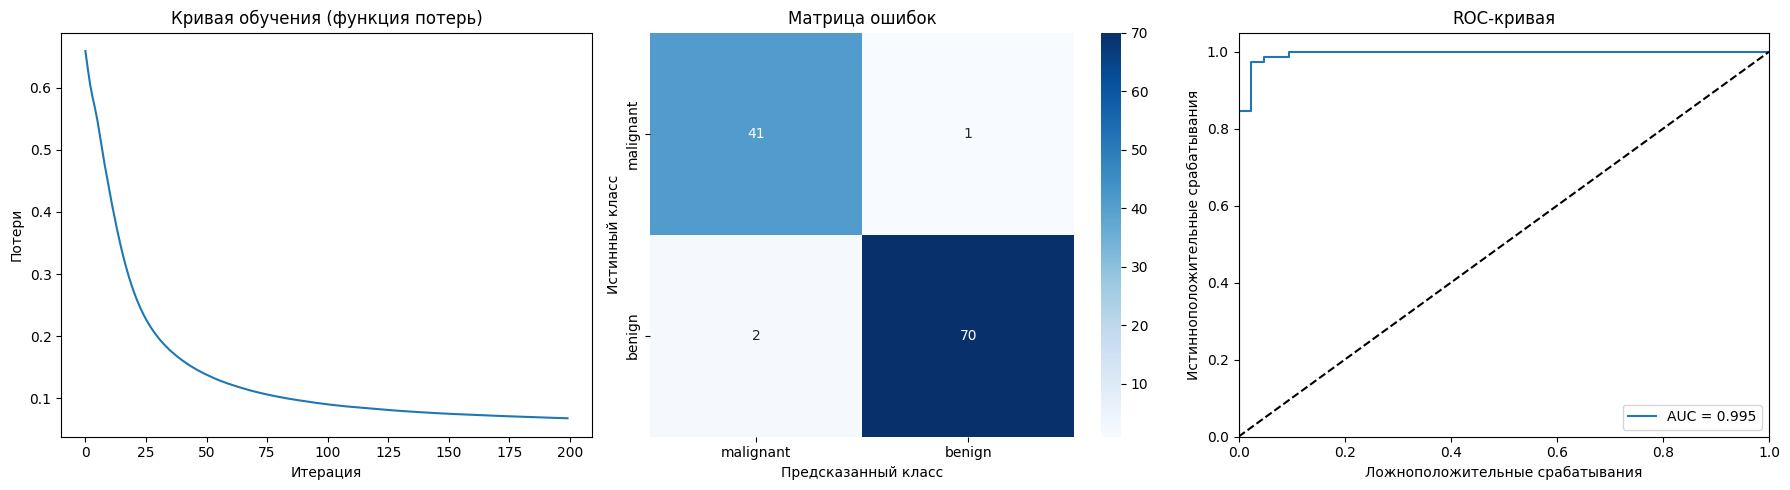

In [183]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# График функции потерь
axes[0].plot(mlp.loss_curve_)
axes[0].set_title('Кривая обучения (функция потерь)')
axes[0].set_xlabel('Итерация')
axes[0].set_ylabel('Потери')

# Тепловая карта матрицы ошибок
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=target_names, yticklabels=target_names, ax=axes[1])
axes[1].set_title('Матрица ошибок')
axes[1].set_xlabel('Предсказанный класс')
axes[1].set_ylabel('Истинный класс')

# ROC-кривая
y_proba = mlp.predict_proba(X_test_scaled)[:, 1]
fpr, tpr, _ = roc_curve(y_test, y_proba)
roc_auc = auc(fpr, tpr)
axes[2].plot(fpr, tpr, label=f'AUC = {roc_auc:.3f}')
axes[2].plot([0, 1], [0, 1], 'k--')
axes[2].set_xlim([0.0, 1.0])
axes[2].set_ylim([0.0, 1.05])
axes[2].set_xlabel('Ложноположительные срабатывания')
axes[2].set_ylabel('Истинноположительные срабатывания')
axes[2].set_title('ROC-кривая')
axes[2].legend(loc='lower right')

plt.tight_layout()
plt.show()